In [1]:
import pandas as pd
from pymatgen.core import Composition
from periodic_trends import plotter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors

import re
from collections import Counter

In [2]:
from plotting_code import apply_style
apply_style("linux")

In [3]:
icsd_test_df = pd.read_csv("control_dataset_splits/ICSD_test_split.csv")
icsd_val_df = pd.read_csv("control_dataset_splits/ICSD_val_split.csv")
icsd_train_df = pd.read_csv("control_dataset_splits/ICSD_train_split.csv")

icsd_df = pd.concat([icsd_train_df, icsd_val_df, icsd_test_df], ignore_index=True)
print(icsd_df.shape)

(2283, 5)


# Periodic table plot

In [4]:
from bokeh.io import output_notebook

output_notebook()

Loading BokehJS ...

In [5]:
my_highlights = ["Mn", "O"]
my_color = "#30d6ff" 

import pandas as pd
pd.Series.iteritems = pd.Series.items

all_elements = []
for formula in icsd_df['Chemical']:
    comp = Composition(formula)
    all_elements.extend([el.symbol for el in comp.elements])

counts_df = pd.Series(all_elements).value_counts().reset_index()
counts_df.columns = ['Element', 'Count']


counts_df.loc[counts_df['Element'].isin(['Mn', 'O']), 'Count'] = np.nan

custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("custom", ["#fbbe23","#e55c30", "#993bff", "#57106e"])

plotter(
    counts_df, 
    "Element", 
    "Count", 
    special_elements=my_highlights,
    special_color=my_color,
    blank_color="#fafafa",
    output_filename="outputs/table.html", 
    width = 1000,
    height = 600,
    cbar_fontsize = 16,
    cmap= custom_cmap,
    alpha= 0.9
)

figure(id='p1007', ...)

[2] Sandbox: CanCreateUserNamespace() clone() failure: EPERM


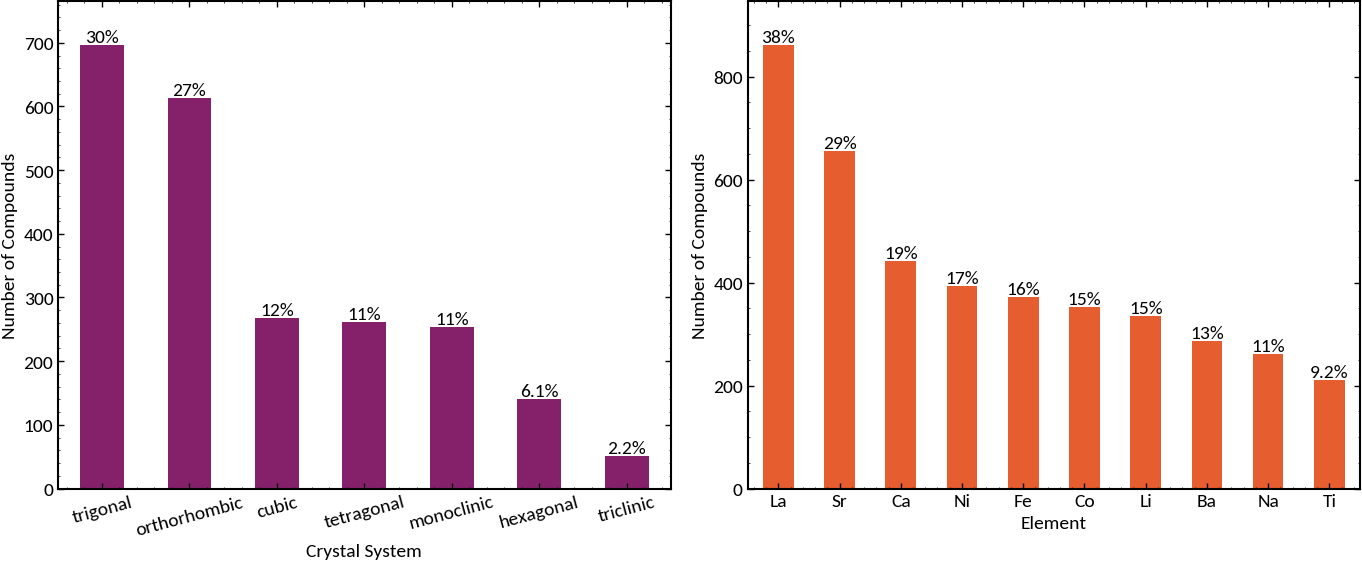

In [6]:
def get_colormap_colors(num_items, colormap='viridis', cmap_range=(0.1, 0.9)):
    cmap = plt.get_cmap(colormap)
    if num_items == 1:
        return [cmap((cmap_range[0] + cmap_range[1]) / 2)]
    else:
        return [
            cmap(cmap_range[0] + (cmap_range[1] - cmap_range[0]) * i / (num_items - 1))
            for i in range(num_items)
        ]

counts = icsd_df['Crystal_System'].value_counts()
total_compounds = len(icsd_df)
bar_colour = get_colormap_colors(4, colormap='inferno')

def get_element_counts(formulas):
    counts = Counter()
    for formula in formulas:
        elements = re.findall(r'([A-Z][a-z]*)', formula)
        for el in elements:
            counts[el] += 1
    return counts

element_counts = get_element_counts(icsd_df['Chemical'])

df_elements = (
    pd.DataFrame.from_dict(element_counts, orient='index', columns=['count'])
    .sort_values(by='count', ascending=False)
    .iloc[2:]        # ← remove the two most common elements
    .head(10)        # ← then take the next 12
)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

counts.plot(kind='bar', ax=ax1, color=bar_colour[1])

for p in ax1.patches:
    percentage = f'{100 * p.get_height() / total_compounds:.2g}%'
    ax1.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=14,
    )

ax1.set_xlabel('Crystal System')
ax1.set_ylabel('Number of Compounds')
ax1.set_ylim(0, counts.max() * 1.1)
ax1.tick_params(axis='x', rotation = 15)

df_elements.plot(kind='bar', ax=ax2, color = bar_colour[2])

for p in ax2.patches:
    percentage = f'{100 * p.get_height() / total_compounds:.2g}%'
    ax2.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=14,
    )

ax2.set_xlabel('Element')
ax2.set_ylabel('Number of Compounds')
ax2.set_ylim(0, df_elements['count'].max() * 1.1)
ax2.tick_params(axis='both', rotation = 0)
ax2.legend().remove()


plt.tight_layout()
plt.show()

# Crystal system analysis

Gtk-Message: 13:37:04.056: Failed to load module "canberra-gtk-module"
Gtk-Message: 13:37:04.056: Failed to load module "canberra-gtk-module"


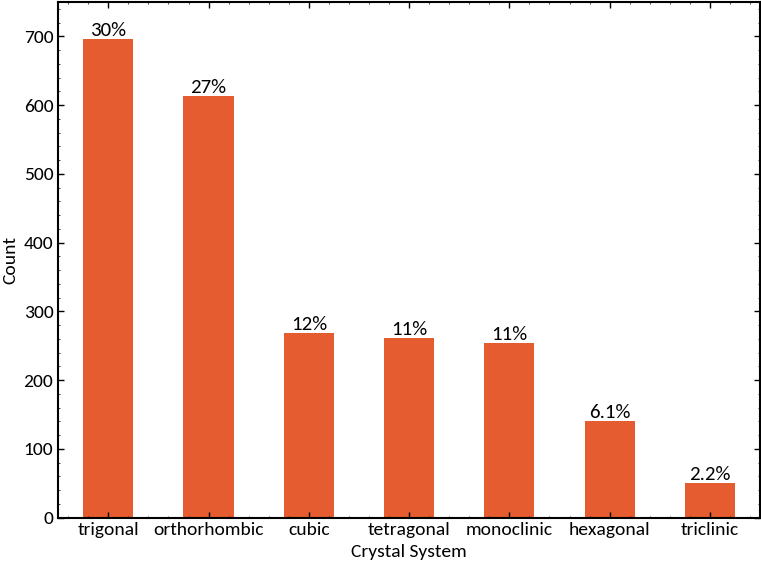

In [7]:
counts = icsd_df['Crystal_System'].value_counts()
total = len(icsd_df)

plt.figure(figsize=(8, 6))
ax = counts.plot(kind='bar', color = "#e55c30")

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2g}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=15)

# 4. Final plot formatting
plt.xlabel('Crystal System')
plt.ylabel('Count')
ax.set_ylim(0, 750)
plt.xticks(rotation=0)
plt.savefig('outputs/elemental_distribution.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

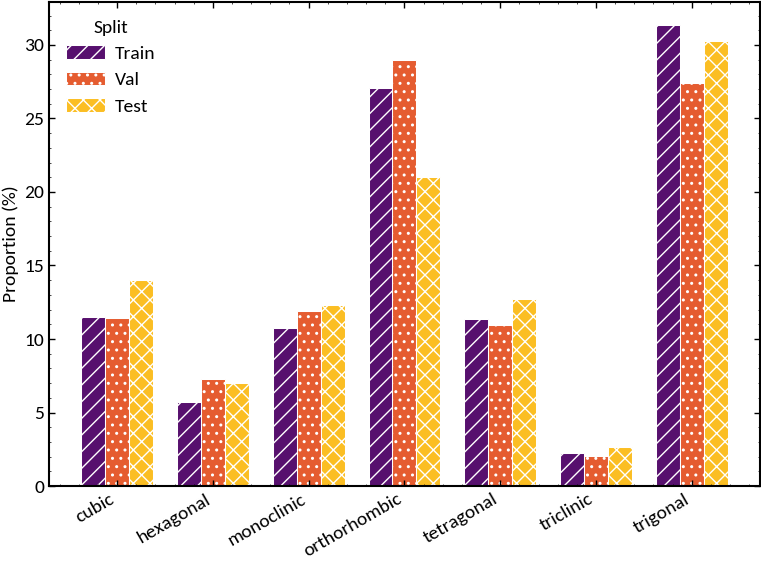

In [8]:
train_dist = icsd_train_df['Crystal_System'].value_counts(normalize=True).sort_index() * 100
val_dist   = icsd_val_df['Crystal_System'].value_counts(normalize=True).sort_index() * 100
test_dist  = icsd_test_df['Crystal_System'].value_counts(normalize=True).sort_index() * 100

crystal_systems = train_dist.index.tolist()
x = np.arange(len(crystal_systems))
width = 0.25

split_colors  = {'Train': '#57106e', 'Val': '#e55c30', 'Test': '#fbbe23'}
split_hatches = {'Train': '//',      'Val': '..',      'Test': 'xx'}

plt.figure(figsize=(8, 6))

for i, (split, dist) in enumerate(zip(
    ['Train', 'Val', 'Test'],
    [train_dist, val_dist, test_dist]
)):
    plt.bar(
        x + (i - 1) * width,
        dist.values,
        width=width,
        color=split_colors[split],
        hatch=split_hatches[split],
        edgecolor='white',
        linewidth=0.75,
        label=split
    )

plt.xticks(x, crystal_systems, rotation=30, ha='right')
plt.ylabel('Proportion (%)')
plt.legend(title='Split', frameon=False)
plt.tight_layout()
plt.savefig('outputs/class_distribution_splits.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
"""
Chemical Formula Template Matcher
==================================
Parses chemical formulae and matches them against known general templates
(perovskite, spinel, layered oxide, YBCO, etc.).

Usage:
    # Match a single formula
    python formula_matcher.py --formula "La0.7Sr0.3MnO3"

    # Match all formulae in a CSV column
    python formula_matcher.py --csv my_data.csv --column formula

    # Match a plain text file (one formula per line)
    python formula_matcher.py --file formulas.txt

    # Write results to CSV
    python formula_matcher.py --csv my_data.csv --column formula --output results.csv

Dependencies: none (standard library only)
"""

import re
import csv
import argparse
import sys
from collections import defaultdict


# ---------------------------------------------------------------------------
# Element classification helpers
# ---------------------------------------------------------------------------

ALKALI = {"Li", "Na", "K", "Rb", "Cs"}
ALKALINE_EARTH = {"Mg", "Ca", "Sr", "Ba"}
RARE_EARTH = {"La", "Ce", "Pr", "Nd", "Sm", "Eu", "Gd", "Tb", "Dy",
              "Ho", "Er", "Tm", "Yb", "Lu", "Y", "Sc"}
TRANSITION_METALS = {
    "Ti","V","Cr","Mn","Fe","Co","Ni","Cu","Zn",
    "Zr","Nb","Mo","Tc","Ru","Rh","Pd","Ag","Cd",
    "Hf","Ta","W","Re","Os","Ir","Pt","Au",
    "Al","Ga","In","Sn","Pb","Bi"
}
HALOGENS = {"F", "Cl", "Br", "I"}


def is_A_site(el):
    return el in ALKALI or el in ALKALINE_EARTH or el in RARE_EARTH or el in {"Bi", "Pb", "Tl"}

def is_B_site(el):
    return el in TRANSITION_METALS


# ---------------------------------------------------------------------------
# Formula parser
# ---------------------------------------------------------------------------

def parse_formula(formula: str) -> dict[str, float]:
    """
    Parse a chemical formula string into {element: stoichiometry}.
    Handles integer and decimal coefficients (e.g. La0.7Sr0.3MnO3).
    Does NOT handle nested parentheses — extend if needed.
    """
    pattern = re.compile(r"([A-Z][a-z]?)(\d*\.?\d*)")
    elems: dict[str, float] = defaultdict(float)
    for match in pattern.finditer(formula):
        el, num = match.group(1), match.group(2)
        if not el:
            continue
        elems[el] += float(num) if num else 1.0
    return dict(elems)


def normalise(elems: dict, by_element: str, to_value: float = 1.0) -> dict:
    """Scale all stoichiometries so that `by_element` equals `to_value`."""
    if by_element not in elems or elems[by_element] == 0:
        return elems
    factor = to_value / elems[by_element]
    return {k: v * factor for k, v in elems.items()}


# ---------------------------------------------------------------------------
# Template library
# ---------------------------------------------------------------------------

def near(a: float, b: float, tol: float = 0.2) -> bool:
    return abs(a - b) < tol


class MatchResult:
    def __init__(self, template_name, formula, description, tags, site_assignments, confidence):
        self.template_name = template_name
        self.formula = formula
        self.description = description
        self.tags = tags
        self.site_assignments = site_assignments  # dict of site -> element(s)
        self.confidence = confidence  # "high" | "medium" | "low"

    def __repr__(self):
        sites = ", ".join(f"{k}={v}" for k, v in self.site_assignments.items())
        return f"[{self.confidence}] {self.template_name} ({self.formula}) — {sites}"


TEMPLATES = []

def template(name, formula, description, tags):
    """Decorator to register a template checker function."""
    def decorator(fn):
        TEMPLATES.append({
            "name": name,
            "formula": formula,
            "description": description,
            "tags": tags,
            "check": fn,
        })
        return fn
    return decorator


# ---- Simple perovskite ABO3 -----------------------------------------------
@template("Perovskite", "ABO₃", "Simple perovskite (e.g. BaTiO₃, SrTiO₃)", ["perovskite","oxide"])
def check_perovskite(elems):
    if "O" not in elems or len(elems) != 3:
        return None
    if not near(elems["O"], 3, tol=0.25):
        return None
    non_o = [e for e in elems if e != "O"]
    total = sum(elems[e] for e in non_o)
    if not near(total, 2, tol=0.25):
        return None
    # Try to assign A/B by element type
    a_els = [e for e in non_o if is_A_site(e)]
    b_els = [e for e in non_o if is_B_site(e)]
    if not a_els or not b_els:
        # Fall back to stoichiometry ordering
        sorted_els = sorted(non_o, key=lambda e: elems[e])
        a_els = [sorted_els[-1]]
        b_els = [sorted_els[0]]
    return MatchResult(
        "Perovskite", "ABO₃",
        "Simple perovskite",
        ["perovskite","oxide"],
        {"A": a_els[0], "B": b_els[0], "O": elems["O"]},
        "high"
    )


# ---- Doped / mixed A-site perovskite (La1-xAxMnO3 type) ------------------
@template("Doped perovskite", "A₁₋ₓA'ₓBO₃", "A-site substituted perovskite (e.g. La0.7Sr0.3MnO3)", ["perovskite","doped","manganite"])
def check_doped_perovskite(elems):
    if "O" not in elems or len(elems) < 4:
        return None
    if not near(elems["O"], 3, tol=0.3):
        return None
    non_o = [e for e in elems if e != "O"]
    # B-site: single element with stoich ~1
    b_els = [e for e in non_o if near(elems[e], 1, tol=0.15) and is_B_site(e)]
    if len(b_els) != 1:
        return None
    b = b_els[0]
    a_els = [e for e in non_o if e != b]
    a_total = sum(elems[e] for e in a_els)
    if not near(a_total, 1, tol=0.2):
        return None
    a_str = " + ".join(f"{e}({elems[e]:.2f})" for e in a_els)
    return MatchResult(
        "Doped perovskite", "A₁₋ₓA'ₓBO₃",
        "A-site substituted perovskite",
        ["perovskite","doped"],
        {"A-site": a_str, "B-site": b, "O": round(elems["O"],3)},
        "high"
    )


# ---- B-site doped perovskite AB1-xB'xO3 -----------------------------------
@template("B-site doped perovskite", "AB₁₋ₓB'ₓO₃", "B-site substituted perovskite", ["perovskite","doped"])
def check_b_doped_perovskite(elems):
    if "O" not in elems or len(elems) < 4:
        return None
    if not near(elems["O"], 3, tol=0.3):
        return None
    non_o = [e for e in elems if e != "O"]
    a_els = [e for e in non_o if near(elems[e], 1, tol=0.15) and is_A_site(e)]
    if len(a_els) != 1:
        return None
    a = a_els[0]
    b_els = [e for e in non_o if e != a]
    b_total = sum(elems[e] for e in b_els)
    if not near(b_total, 1, tol=0.2):
        return None
    b_str = " + ".join(f"{e}({elems[e]:.2f})" for e in b_els)
    return MatchResult(
        "B-site doped perovskite", "AB₁₋ₓB'ₓO₃",
        "B-site substituted perovskite",
        ["perovskite","doped"],
        {"A-site": a, "B-site": b_str, "O": round(elems["O"],3)},
        "medium"
    )


# ---- Layered AMO2 (NaAxO2 / LiCoO2 type) ----------------------------------
@template("Layered oxide", "AMO₂", "Layered rock-salt oxide (e.g. NaCoO₂, LiCoO₂)", ["layered","cathode","oxide"])
def check_layered_amo2(elems):
    if "O" not in elems:
        return None
    if not near(elems["O"], 2, tol=0.2):
        return None
    non_o = [e for e in elems if e != "O"]
    a = next((e for e in non_o if e in ALKALI), None)
    if not a:
        return None
    m = next((e for e in non_o if e != a), None)
    return MatchResult(
        "Layered oxide", "AMO₂",
        "Layered oxide / O3 / P2 structure",
        ["layered","cathode","oxide"],
        {"A (alkali)": f"{a}({elems[a]:.2f})", "M (TM)": m, "O": elems["O"]},
        "high"
    )


# ---- Spinel AB2O4 ----------------------------------------------------------
@template("Spinel", "AB₂O₄", "Normal spinel (e.g. LiMn₂O₄, MgAl₂O₄)", ["spinel","oxide"])
def check_spinel(elems):
    if "O" not in elems:
        return None
    if not near(elems["O"], 4, tol=0.3):
        return None
    non_o = [e for e in elems if e != "O"]
    if len(non_o) != 2:
        return None
    sorted_els = sorted(non_o, key=lambda e: elems[e])
    a, b = sorted_els[0], sorted_els[1]
    if not near(elems[a], 1, tol=0.2):
        return None
    if not near(elems[b], 2, tol=0.2):
        return None
    return MatchResult(
        "Spinel", "AB₂O₄",
        "Normal spinel",
        ["spinel","oxide"],
        {"A (tet)": a, "B (oct)": b, "O": elems["O"]},
        "high"
    )


# ---- Inverse spinel / magnetite A3O4 (single TM) --------------------------
@template("Inverse spinel", "A₃O₄", "Inverse spinel / magnetite-type (e.g. Fe₃O₄)", ["spinel","magnetite"])
def check_inverse_spinel(elems):
    if "O" not in elems or len(elems) != 2:
        return None
    tm = next((e for e in elems if e != "O"), None)
    if not near(elems[tm], 3, tol=0.25) or not near(elems["O"], 4, tol=0.25):
        return None
    return MatchResult(
        "Inverse spinel", "A₃O₄",
        "Inverse spinel / magnetite-type (mixed valence)",
        ["spinel","magnetite"],
        {"M (mixed valence)": tm, "O": elems["O"]},
        "high"
    )


# ---------------------------------------------------------------------------
# Main matching function
# ---------------------------------------------------------------------------

def match_formula(formula: str) -> list[MatchResult]:
    """Return all matching templates for a given formula string."""
    elems = parse_formula(formula)
    if not elems:
        return []
    results = []
    for tmpl in TEMPLATES:
        result = tmpl["check"](elems)
        if result:
            results.append(result)
    return results


def format_result(formula: str, matches: list[MatchResult]) -> str:
    lines = [f"\nFormula: {formula}"]
    if not matches:
        lines.append("  → No matching template found.")
    else:
        for m in matches:
            lines.append(f"  ✓ {m.template_name} ({m.formula})")
            lines.append(f"    {m.description}")
            for site, val in m.site_assignments.items():
                lines.append(f"    {site}: {val}")
            lines.append(f"    Tags: {', '.join(m.tags)}")
    return "\n".join(lines)


# ---------------------------------------------------------------------------
# CSV / file processing
# ---------------------------------------------------------------------------

def process_csv(filepath: str, column: str, output: str | None = None):
    with open(filepath, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        if column not in reader.fieldnames:
            print(f"Error: column '{column}' not found. Available: {reader.fieldnames}")
            sys.exit(1)
        rows = list(reader)

    result_rows = []
    for row in rows:
        formula = row[column].strip()
        matches = match_formula(formula)
        row["matched_templates"] = "; ".join(m.template_name for m in matches) if matches else "No match"
        row["matched_formulas"] = "; ".join(m.formula for m in matches) if matches else ""
        row["tags"] = "; ".join(",".join(m.tags) for m in matches) if matches else ""
        row["site_assignments"] = "; ".join(
            " | ".join(f"{k}={v}" for k,v in m.site_assignments.items()) for m in matches
        ) if matches else ""
        result_rows.append(row)
        print(format_result(formula, matches))

    if output:
        fieldnames = list(rows[0].keys()) + ["matched_templates","matched_formulas","tags","site_assignments"]
        with open(output, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(result_rows)
        print(f"\nResults written to: {output}")


def process_file(filepath: str):
    with open(filepath, encoding="utf-8") as f:
        formulas = [line.strip() for line in f if line.strip()]
    for formula in formulas:
        matches = match_formula(formula)
        print(format_result(formula, matches))


In [10]:
import pandas as pd

df = pd.read_csv("ICSD_CrystStrucData.csv")
df['formula'] = df['Chemical']
df.head()

,HMS,Chemical,Temperature,Pressure,Crystal_System,formula
0,P 4/m m m,Nd1Ba1Mn1Fe1O5.45,293.0,0.101325,tetragonal,Nd1Ba1Mn1Fe1O5.45
1,P 4/m m m,Nd1Ba1Mn1Fe1O5.17,293.0,0.101325,tetragonal,Nd1Ba1Mn1Fe1O5.17
2,P 4/m m m,Nd1Ba1Mn1Fe1O5.09,293.0,0.101325,tetragonal,Nd1Ba1Mn1Fe1O5.09
3,I 4/m m m,Sr2Mn2.275Cr0.725As2O2,300.0,0.101325,tetragonal,Sr2Mn2.275Cr0.725As2O2
4,P 42 m c,Ca1Mn1Ti1.8V0.2O6,293.0,0.101325,tetragonal,Ca1Mn1Ti1.8V0.2O6


In [11]:
def get_templates(formula):
    matches = match_formula(formula)
    return [m.template_name for m in matches] if matches else ["No match"]

df["templates"] = df["formula"].apply(get_templates)

In [12]:
df_exploded = df.explode("templates")

In [13]:
counts = df_exploded["templates"].value_counts()
percentages = df_exploded["templates"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "count": counts,
    "percentage": percentages
})

summary

,count,percentage
templates,,
No match,1305,56.177357
Doped perovskite,645,27.765820
Layered oxide,307,13.215669
B-site doped perovskite,66,2.841154


In [14]:
no_match_df = df_exploded[df_exploded["templates"] == "No match"]
no_match_df

,HMS,Chemical,Temperature,Pressure,Crystal_System,formula,templates
0,P 4/m m m,Nd1Ba1Mn1Fe1O5.45,293.0,0.101325,tetragonal,Nd1Ba1Mn1Fe1O5.45,No match
1,P 4/m m m,Nd1Ba1Mn1Fe1O5.17,293.0,0.101325,tetragonal,Nd1Ba1Mn1Fe1O5.17,No match
2,P 4/m m m,Nd1Ba1Mn1Fe1O5.09,293.0,0.101325,tetragonal,Nd1Ba1Mn1Fe1O5.09,No match
3,I 4/m m m,Sr2Mn2.275Cr0.725As2O2,300.0,0.101325,tetragonal,Sr2Mn2.275Cr0.725As2O2,No match
4,P 42 m c,Ca1Mn1Ti1.8V0.2O6,293.0,0.101325,tetragonal,Ca1Mn1Ti1.8V0.2O6,No match
...,...,...,...,...,...,...,...
2294,F d -3 Z,Mn21.5Rb49Al92Si100O384,294.0,0.101325,cubic,Mn21.5Rb49Al92Si100O384,No match
2295,F 4 3 2,Ca6.3Mn3Ga4.4Al1.3O18,293.0,0.101325,cubic,Ca6.3Mn3Ga4.4Al1.3O18,No match
2296,F -4 3 m,Li1In1Cr3.8Mn0.2O8,293.0,0.101325,cubic,Li1In1Cr3.8Mn0.2O8,No match
2297,F -4 3 m,Li1In1Cr3.6Mn0.4O8,293.0,0.101325,cubic,Li1In1Cr3.6Mn0.4O8,No match
